<a href="https://colab.research.google.com/github/preksha-j-amin12/Machine-Learning/blob/main/student_performance_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- Dataset Preview ---
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Co

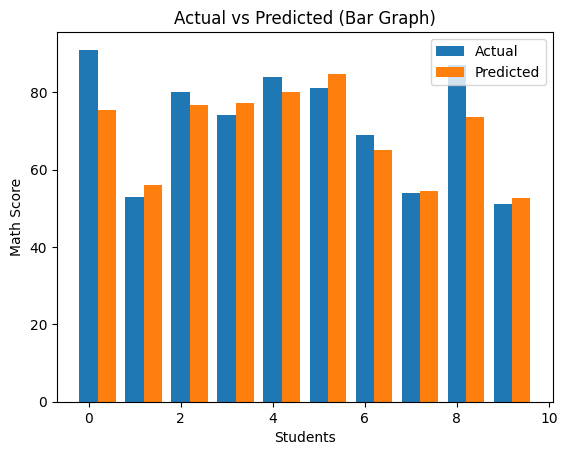

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("StudentsPerformance.csv")

# 🔹 1. Show first 5 rows (Table)
print("\n--- Dataset Preview ---")
print(df.head())

# 🔹 2. Dataset Info Table
print("\n--- Dataset Info ---")
print(df.info())

# 🔹 3. Statistical Summary Table
print("\n--- Statistical Summary ---")
print(df.describe())

# Convert categorical columns to numeric
df = pd.get_dummies(df, drop_first=True)

# Features and target
X = df.drop("math score", axis=1)
y = df["math score"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# 🔹 4. Evaluation Table
results = pd.DataFrame({
    "Metric": ["MSE", "R2 Score"],
    "Value": [mean_squared_error(y_test, y_pred), r2_score(y_test, y_pred)]
})

print("\n--- Model Evaluation ---")
print(results)

# 🔹 5. Actual vs Predicted Table
comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

print("\n--- Actual vs Predicted (First 10) ---")
print(comparison)

# 🔹 6. Feature Importance Table
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\n--- Feature Importance ---")
print(importance.head(10))

# 📊 BAR GRAPH
n = 10
x = range(n)

plt.bar(x, y_test.values[:n], width=0.4, label="Actual")
plt.bar([i + 0.4 for i in x], y_pred[:n], width=0.4, label="Predicted")

plt.xlabel("Students")
plt.ylabel("Math Score")
plt.title("Actual vs Predicted (Bar Graph)")
plt.legend()

plt.show()